In [113]:
'''
Use data from the literature to directly compare autaptic and synapse properties

'''

import numpy as np
import pandas as pandas
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# AQUA supplies the neuron/autapse model wrapper used to build Brian2 objects.
import aqua
from aqua.batchAQUA_general import batchAQUA

# Brian2 units, monitors, and network primitives are imported into the namespace.
from brian2 import *

In [114]:
# import data 

filename = 'autapse_properties_updated.csv'
df = pd.read_csv(filename)
print(df.keys())

df['Study'] = df['Author'] + " (" + df['Year'].astype(str) + ")"

print(df.head())


Index(['Author', 'Year', 'autapse', 'neuron type', 'E/I', 'peak current (pA)',
       'peak current (pA)_std', 'CV aEPSC', 'CV aEPSC_std', 'failure rate',
       'failure rate_std', 'onset latency (ms)', 'onset latency (ms)_std',
       'rise time (ms)', 'rise time (ms)_std', 'decay time (ms)',
       'decay time (ms)_std', 'probability of release',
       'probability of release_std', 'paired-pulse ratio',
       'paired-pulse ratio_std'],
      dtype='object')
           Author  Year  autapse neuron type E/I  peak current (pA)  \
0      Yin et al.  2018     True          PC   E             149.00   
1      Yin et al.  2018    False       PC-PC   E              28.60   
2    Bacci et al.  2003     True          FS   I            -352.30   
3  Deleuze et al.  2019     True          PV   I            -451.82   
4  Deleuze et al.  2019    False       PV-PC   I            -146.87   

   peak current (pA)_std  CV aEPSC  CV aEPSC_std  failure rate  ...  \
0                  11.00      0.25 

In [115]:
## Only look at the studies which look explicitly compare autapses to synapses.

# Clean up trailing whitespace in string columns if present
df['Author'] = df['Author'].str.strip()

# Convert autapse column values to standardized boolean/string representation
df['autapse_bool'] = df['autapse'].astype(str).str.upper()

# Filter groups that contain both 'TRUE' and 'FALSE'
filtered_df = df.groupby(['Author', 'Year']).filter(
    lambda group: {'TRUE', 'FALSE'}.issubset(set(group['autapse_bool']))
).drop(columns=['autapse_bool'])
filtered_df['Study'] = filtered_df['Author'] + " (" + filtered_df['Year'].astype(str) + ")"
# Print the resulting DataFrame
print(filtered_df)


               Author  Year  autapse       neuron type E/I  peak current (pA)  \
0          Yin et al.  2018     True                PC   E             149.00   
1          Yin et al.  2018    False             PC-PC   E              28.60   
3      Deleuze et al.  2019     True                PV   I            -451.82   
4      Deleuze et al.  2019    False             PV-PC   I            -146.87   
5      Deleuze et al.  2019    False             PV-PV   I            -246.11   
8      Pouzat & Marty  1998     True               NaN   I             -12.50   
9      Pouzat & Marty  1998    False               NaN   I             -56.00   
10  Karayannis et al.  2010     True              NGFC   I            -114.10   
11  Karayannis et al.  2010    False              NGFC   I             -85.00   
12       Jiang et al.  2012     True                FS   I            -255.80   
13       Jiang et al.  2012    False             FS-FS   I             -58.10   
14       Jiang et al.  2012 

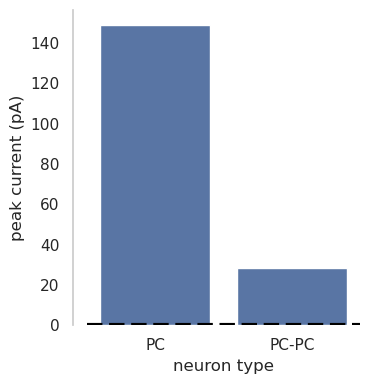

In [117]:
## Only plot the distribution of peak current values (with error bars)
studies = ['Yin et al. (2018)']

fig, ax = plt.subplots(1, len(studies), figsize = (4*len(studies), 4), sharey = True)
sns.despine(fig = fig, right = True, top = True, bottom = True)

for n, study in enumerate(studies):
    sub_df = df[df['Study'] == study].copy()

    sns.barplot(data = sub_df, x = 'neuron type', y = 'peak current (pA)', ax = ax)
    ax.grid(False)
    ax.hlines(y = 0, xmin = ax.get_xlim()[0], xmax = ax.get_xlim()[1], 
                 linestyle = '--', color = 'black', linewidth = 3)
    #ax[n].xticks(rotation=45, ha='right')

fig.tight_layout()
plt.savefig('./plots/Figure 2/peak_currents_E.svg')

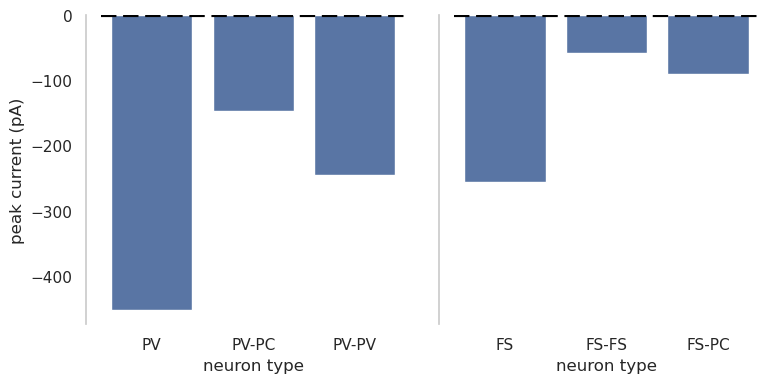

In [118]:
## Only plot the distribution of peak current values (with error bars)
studies =  ['Deleuze et al. (2019)', 'Jiang et al. (2012)'] # ['Yin et al. (2018)']

fig, ax = plt.subplots(1, len(studies), figsize = (4*len(studies), 4), sharey = True)
sns.despine(fig = fig, right = True, top = True, bottom = True)

for n, study in enumerate(studies):
    sub_df = df[df['Study'] == study].copy()

    sns.barplot(data = sub_df, x = 'neuron type', y = 'peak current (pA)', ax = ax[n])
    ax[n].grid(False)
    ax[n].hlines(y = 0, xmin = ax[n].get_xlim()[0], xmax = ax[n].get_xlim()[1], 
                 linestyle = '--', color = 'black', linewidth = 3)
    #ax[n].xticks(rotation=45, ha='right')

fig.tight_layout()
plt.savefig('./plots/Figure 2/peak_currents_I.svg')


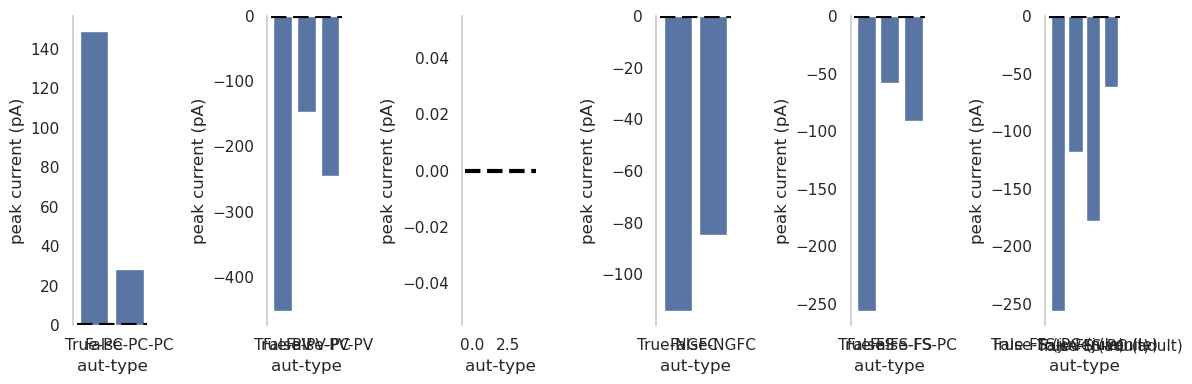

In [119]:
## Only plot the distribution of peak current values (with error bars)
studies = ['Yin et al. (2018)', 'Deleuze et al. (2019)', 'Pouzat & Marty (1998)', 'Karayannis et al. (2010)',
           'Jiang et al. (2012)', 'Jiang et al. (2015)']

fig, ax = plt.subplots(1, len(studies), figsize = (12, 4))
sns.despine(fig = fig, right = True, top = True, bottom = True)

for n, study in enumerate(studies):
    sub_df = df[df['Study'] == study].copy()
    sub_df['aut-type'] = sub_df['autapse'].astype(str) + '-' + sub_df['neuron type']

    sns.barplot(data = sub_df, x = 'aut-type', y = 'peak current (pA)', ax = ax[n])
    ax[n].grid(False)
    ax[n].hlines(y = 0, xmin = ax[n].get_xlim()[0], xmax = ax[n].get_xlim()[1], 
                 linestyle = '--', color = 'black', linewidth = 3)
    #ax[n].xticks(rotation=45, ha='right')

fig.tight_layout()

<Axes: xlabel='decay time (ms)', ylabel='peak current (pA)'>

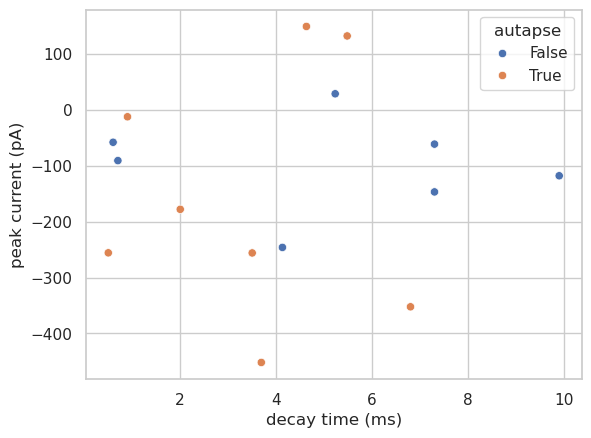

In [120]:


sns.scatterplot(data = df, x = 'decay time (ms)', y = 'peak current (pA)', hue = 'autapse')